In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Cargar los datos
datos = pd.read_csv("datos_ventas_multiples_productos.csv")

# Convertimos la columna de mes a un valor numérico (mes) si es una fecha completa
datos["mes"] = pd.to_datetime(datos["mes"]).dt.month

# Lista de productos únicos
productos = datos["producto"].unique()


Producto A:
  - Error cuadrático medio para Unidades: 251.21
  - Error cuadrático medio para Precio de Venta: 0.00
  - Error cuadrático medio para Precio de Compra: 0.14

Producto B:
  - Error cuadrático medio para Unidades: 100.40
  - Error cuadrático medio para Precio de Venta: 0.00
  - Error cuadrático medio para Precio de Compra: 0.49

Producto C:
  - Error cuadrático medio para Unidades: 242.09
  - Error cuadrático medio para Precio de Venta: 0.00
  - Error cuadrático medio para Precio de Compra: 0.50


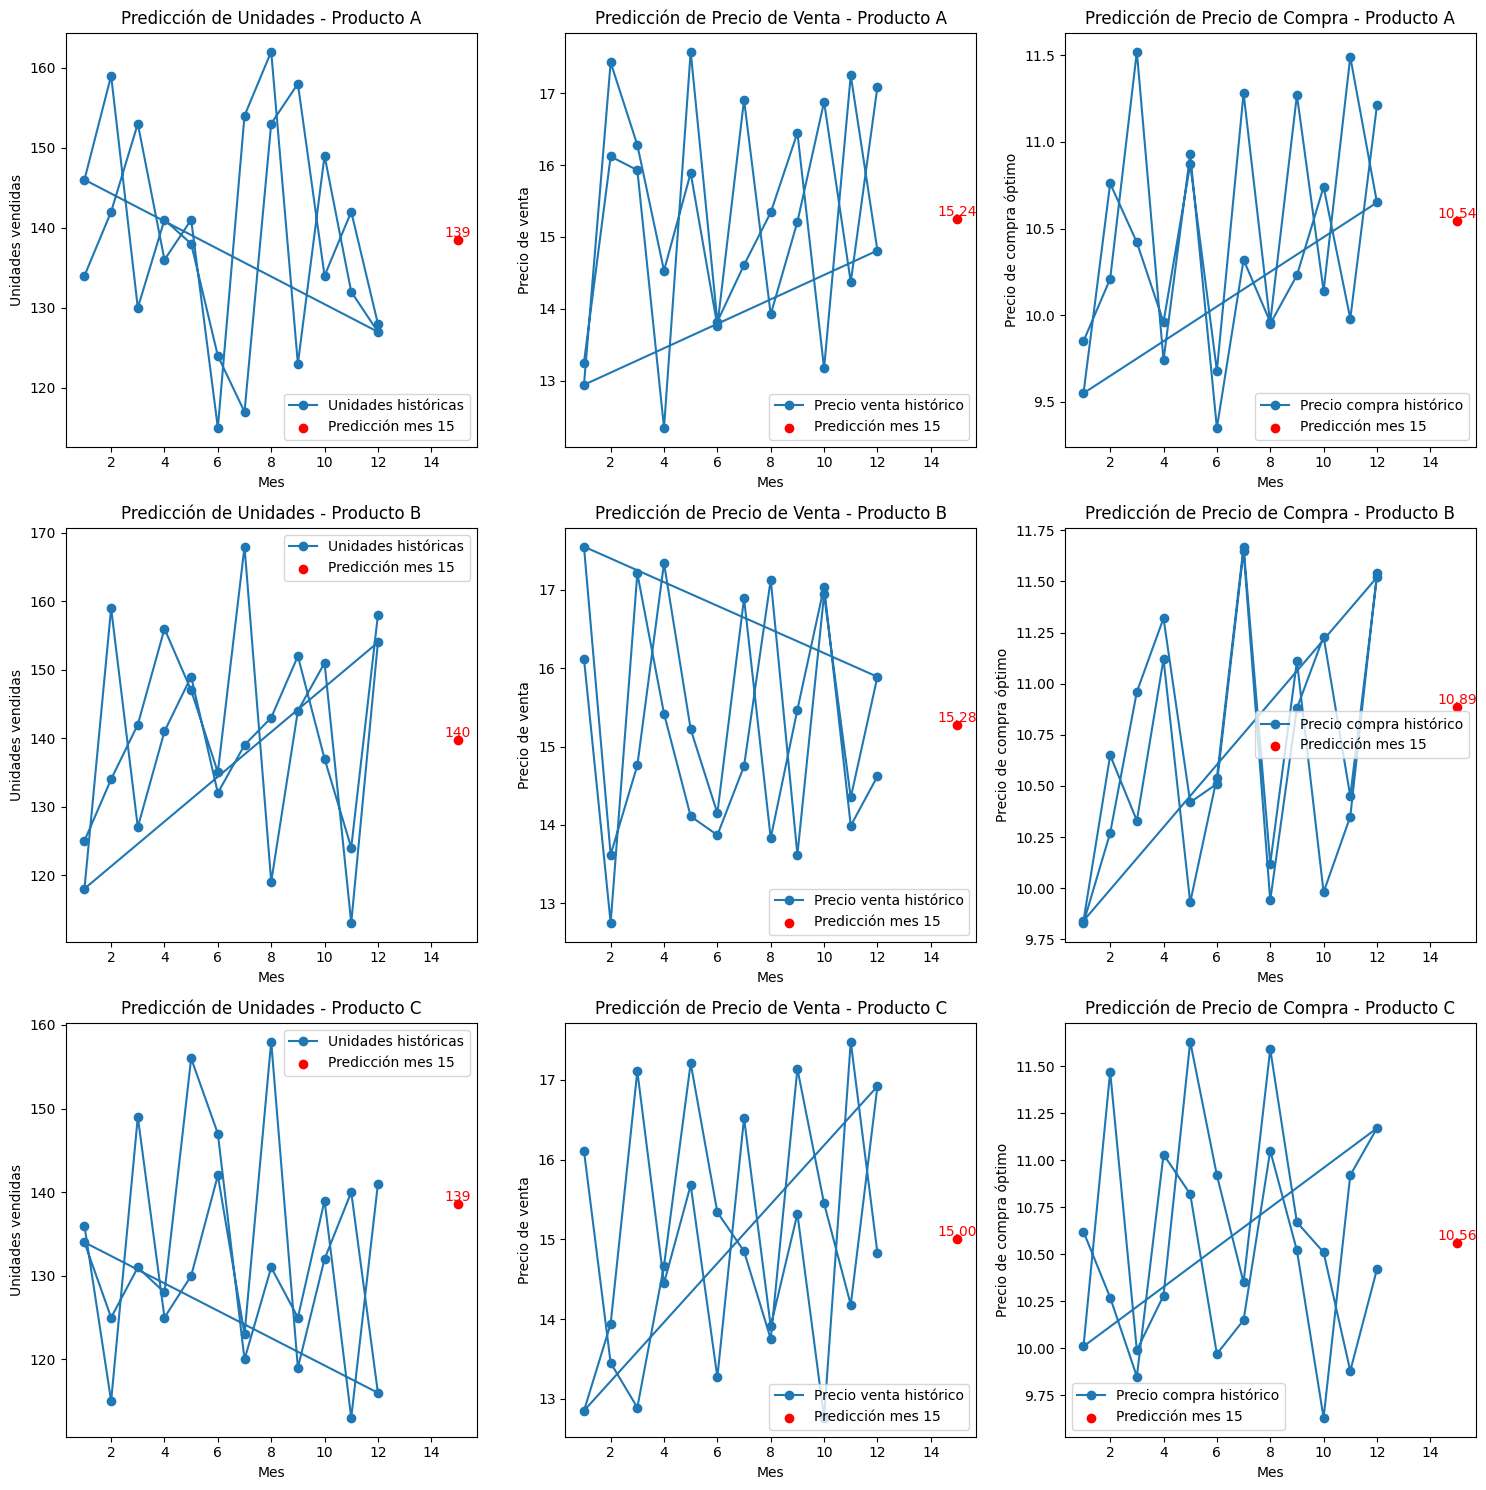

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Inicializar los gráficos
plt.figure(figsize=(15, len(productos) * 5))

# Loop para cada producto
for i, producto in enumerate(productos):
    # Filtrar los datos por producto
    datos_producto = datos[datos["producto"] == producto]
    
    # Definir variables predictoras y objetivos
    X = datos_producto[["mes", "precio_venta"]]
    y_unidades = datos_producto["unidades_vendidas"]
    y_precio = datos_producto["precio_venta"]
    y_compra = datos_producto["precio_compra"]
    
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_unidades_train, y_unidades_test = train_test_split(X, y_unidades, test_size=0.2, random_state=42)
    _, _, y_precio_train, y_precio_test = train_test_split(X, y_precio, test_size=0.2, random_state=42)
    _, _, y_compra_train, y_compra_test = train_test_split(X, y_compra, test_size=0.2, random_state=42)
    
    # Entrenar modelos para unidades, precio de venta y precio de compra
    modelo_unidades = LinearRegression().fit(X_train, y_unidades_train)
    modelo_precio = LinearRegression().fit(X_train, y_precio_train)
    modelo_compra = LinearRegression().fit(X_train, y_compra_train)
    
    # Definir el mes de predicción
    nuevo_mes = pd.DataFrame({"mes": [15], "precio_venta": [y_precio.mean()]})
    
    # Predicciones para el mes 15
    unidades_pred = modelo_unidades.predict(nuevo_mes)[0]
    precio_venta_pred = modelo_precio.predict(nuevo_mes)[0]
    precio_compra_pred = modelo_compra.predict(nuevo_mes)[0]
    
    # Cálculo de error cuadrático medio
    mse_unidades = mean_squared_error(y_unidades_test, modelo_unidades.predict(X_test))
    mse_precio = mean_squared_error(y_precio_test, modelo_precio.predict(X_test))
    mse_compra = mean_squared_error(y_compra_test, modelo_compra.predict(X_test))
    
    # Mostrar los errores fuera de la gráfica
    print(f"\nProducto {producto}:")
    print(f"  - Error cuadrático medio para Unidades: {mse_unidades:.2f}")
    print(f"  - Error cuadrático medio para Precio de Venta: {mse_precio:.2f}")
    print(f"  - Error cuadrático medio para Precio de Compra: {mse_compra:.2f}")
    
    # Gráficos para el producto actual
    plt.subplot(len(productos), 3, i * 3 + 1)
    plt.plot(datos_producto["mes"], datos_producto["unidades_vendidas"], label="Unidades históricas", marker='o')
    plt.scatter(15, unidades_pred, color="red", label="Predicción mes 15")
    plt.text(15, unidades_pred, f"{unidades_pred:.0f}", color="red", ha='center', va='bottom')
    plt.xlabel("Mes")
    plt.ylabel("Unidades vendidas")
    plt.title(f"Predicción de Unidades - Producto {producto}")
    plt.legend()
    
    plt.subplot(len(productos), 3, i * 3 + 2)
    plt.plot(datos_producto["mes"], datos_producto["precio_venta"], label="Precio venta histórico", marker='o')
    plt.scatter(15, precio_venta_pred, color="red", label="Predicción mes 15")
    plt.text(15, precio_venta_pred, f"{precio_venta_pred:.2f}", color="red", ha='center', va='bottom')
    plt.xlabel("Mes")
    plt.ylabel("Precio de venta")
    plt.title(f"Predicción de Precio de Venta - Producto {producto}")
    plt.legend()
    
    plt.subplot(len(productos), 3, i * 3 + 3)
    plt.plot(datos_producto["mes"], datos_producto["precio_compra"], label="Precio compra histórico", marker='o')
    plt.scatter(15, precio_compra_pred, color="red", label="Predicción mes 15")
    plt.text(15, precio_compra_pred, f"{precio_compra_pred:.2f}", color="red", ha='center', va='bottom')
    plt.xlabel("Mes")
    plt.ylabel("Precio de compra óptimo")
    plt.title(f"Predicción de Precio de Compra - Producto {producto}")
    plt.legend()

# Mostrar todos los gráficos
plt.tight_layout()
plt.show()